# Retail Sales Analytics Project

## Objective
- Analyze retail sales data to uncover revenue trends, customer behavior, product performance, and profitability insights
- to support business decision-making.

In [36]:
pip install pandas xlrd sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

In [2]:
file = "Superstore.xls"

orders = pd.read_excel(file, sheet_name="Orders")
returns = pd.read_excel(file, sheet_name="Returns")
people = pd.read_excel(file, sheet_name="People")

## Dataset Description

# This dataset contains three tables:

- Orders -- transaction records  
- Returns -- returned orders  
- People -- regional managers  

Orders is the main fact table.

In [4]:
orders.shape

(9994, 21)

In [5]:
returns.shape

(296, 2)

In [6]:
people.shape

(4, 2)

In [9]:
orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
returns.head()

,Returned,Order ID
0,Yes,CA-2017-153822
1,Yes,CA-2017-129707
2,Yes,CA-2014-152345
3,Yes,CA-2015-156440
4,Yes,US-2017-155999


In [11]:
people.head()

,Person,Region
0,Anna Andreadi,West
1,Chuck Magee,East
2,Kelly Williams,Central
3,Cassandra Brandow,South


In [12]:
orders.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [13]:
orders.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [14]:
orders.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [15]:
orders.duplicated().sum()

np.int64(0)

## Data Quality Check

- No major missing values or duplicates were found.  
- Dataset is clean and ready for analysis.

In [16]:
orders.columns = orders.columns.str.replace(" ", "_")
returns.columns = returns.columns.str.replace(" ", "_")
people.columns = people.columns.str.replace(" ", "_")

In [17]:
orders.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category',
       'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [21]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///superstore.db")
people.to_sql("people", engine, index=False, if_exists="replace")

4

In [22]:
orders.to_sql("orders", engine, index=False, if_exists="replace")

9994

In [23]:
returns.to_sql("returns", engine, index=False, if_exists="replace")

296

In [34]:
# LOAD DATA
orders_df = pd.read_sql("SELECT * FROM orders", engine)
returns_df = pd.read_sql("SELECT * FROM returns", engine)
people_df = pd.read_sql("SELECT * FROM people", engine)

## Analysis Phase

- Now that data is stored and retrieved from SQL database, we begin business analysis.

In [24]:
pd.read_sql("SELECT SUM(Sales) AS TotalRevenue FROM orders;", engine)

,TotalRevenue
0,2.297201e+06


# Insight:
- This value represents total revenue generated by the company across all transactions.

In [25]:
query = """
SELECT strftime('%Y-%m', Order_Date) AS Month,
SUM(Sales) AS Revenue
FROM orders
GROUP BY Month
ORDER BY Month;
"""
pd.read_sql(query, engine)

,Month,Revenue
0,2014-01,14236.8950
1,2014-02,4519.8920
2,2014-03,55691.0090
3,2014-04,28295.3450
4,2014-05,23648.2870
5,2014-06,34595.1276
6,2014-07,33946.3930
7,2014-08,27909.4685
8,2014-09,81777.3508
9,2014-10,31453.3930


# Insight:
- Monthly revenue trend helps identify seasonal sales patterns and growth periods.

In [26]:
query = """
SELECT Customer_Name, SUM(Sales) AS TotalSpent
FROM orders
GROUP BY Customer_Name
ORDER BY TotalSpent DESC
LIMIT 10;
"""
pd.read_sql(query, engine)

,Customer_Name,TotalSpent
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571
5,Ken Lonsdale,14175.229
6,Sanjit Chand,14142.334
7,Hunter Lopez,12873.298
8,Sanjit Engle,12209.438
9,Christopher Conant,12129.072


# Insight:
- Top customers contribute disproportionately to total revenue, indicating importance of customer retention strategies.

In [27]:
query = """
SELECT Category, SUM(Profit) AS Profit
FROM orders
GROUP BY Category
ORDER BY Profit DESC;
"""
pd.read_sql(query, engine)

,Category,Profit
0,Technology,145454.9481
1,Office Supplies,122490.8008
2,Furniture,18451.2728


# Insight:
- Technology category generates highest profit while Furniture performs weakest.

In [28]:
query = """
SELECT COUNT(r.Order_ID)*100.0/COUNT(o.Order_ID) AS ReturnRate
FROM orders o
LEFT JOIN returns r
ON o.Order_ID = r.Order_ID;
"""
pd.read_sql(query, engine)

,ReturnRate
0,8.004803


# Insight:
- Return rate indicates product satisfaction and logistics quality. Higher return rates may signal operational issues.

In [30]:
query = """
SELECT Region, Customer_Name, Sales
FROM orders
ORDER BY Region, Sales DESC;
"""
pd.read_sql(query, engine)

,Region,Customer_Name,Sales
0,Central,Tamara Chand,17499.950
1,Central,Adrian Barton,9892.740
2,Central,Sanjit Chand,9449.950
3,Central,Becky Martin,8159.952
4,Central,Andy Reiter,5443.960
...,...,...,...
9989,West,Ivan Gibson,1.344
9990,West,Pamela Coakley,1.188
9991,West,Tamara Dahlen,1.080
9992,West,Zuschuss Carroll,1.080


# Insight:
- Sorting sales by region helps identify top-performing geographic markets.

In [35]:
orders_df["Rank"] = orders_df.groupby("Region")["Sales"].rank(method="dense", ascending=False)

orders_df[orders_df["Rank"] <= 3][["Region","Customer_Name","Sales","Rank"]].sort_values(["Region","Rank"])

,Region,Customer_Name,Sales,Rank
6826,Central,Tamara Chand,17499.950,1.0
9039,Central,Adrian Barton,9892.740,2.0
4098,Central,Sanjit Chand,9449.950,3.0
2623,East,Tom Ashbrook,11199.968,1.0
4190,East,Hunter Lopez,10499.970,2.0
4277,East,Bill Shonely,9099.930,3.0
2697,South,Sean Miller,22638.480,1.0
8488,South,Sanjit Engle,8749.950,2.0
683,South,Grant Thornton,7999.980,3.0
8153,West,Raymond Buch,13999.960,1.0


# Insight:
- Top-ranked customers in each region represent high-value clients and should be targeted for loyalty programs.

<Axes: title={'center': 'Sales by Category'}, xlabel='Category'>

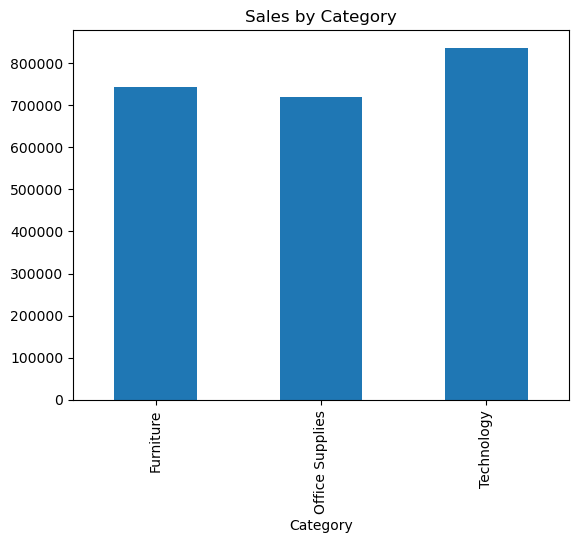

In [37]:
orders_df.groupby("Category")["Sales"].sum().plot(kind="bar", title="Sales by Category")

- The Technology category is the strongest revenue driver for the business.
- Customers are spending more on tech products than any other category, suggesting high demand and possibly higher-priced items.
- Furniture and Office Supplies perform slightly lower, which may indicate either lower pricing or lower purchase frequency.
- The company should prioritize marketing and inventory planning for Technology products since they generate the most revenue.

<Axes: >

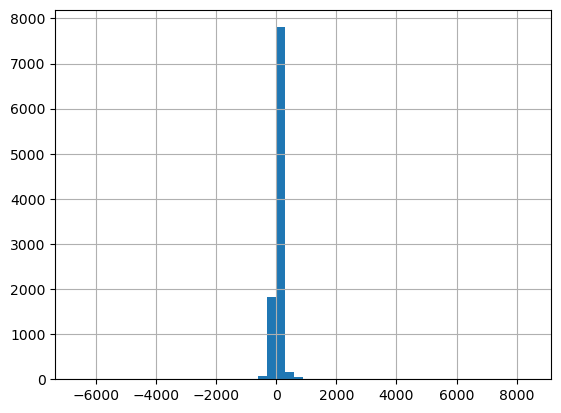

In [38]:
orders_df["Profit"].hist(bins=50)

- The majority of transactions generate low profit margins, meaning most sales contribute only small amounts to overall profitability.
- There are a few extreme cases where profit is very high or very negative, indicating occasional high-margin deals or significant losses.
- This suggests the business operates mostly on thin margins and should analyze why certain orders result in large losses to reduce financial risk.

<Axes: xlabel='Order_Date'>

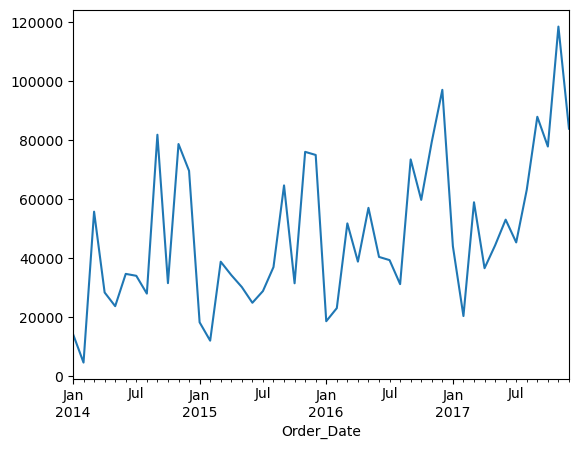

In [39]:
orders_df["Order_Date"] = pd.to_datetime(orders_df["Order_Date"])
orders_df.groupby(orders_df["Order_Date"].dt.to_period("M"))["Sales"].sum().plot()

- Sales show clear fluctuations across months, which suggests seasonal buying patterns or promotional cycles.
- Despite the ups and downs, there is a noticeable upward trend over time, indicating overall business growth.
- This means the company is expanding its revenue base, but should analyze the months with low sales to identify potential improvements in marketing or operations.

In [40]:
total_sales = orders_df["Sales"].sum()
total_profit = orders_df["Profit"].sum()
total_orders = len(orders_df)
avg_order_value = orders_df["Sales"].mean()

print("KEY BUSINESS METRICS")
print("----------------------")
print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Avg Order Value:", avg_order_value)

KEY BUSINESS METRICS
----------------------
Total Sales: 2297200.8603
Total Profit: 286397.0216999999
Total Orders: 9994
Avg Order Value: 229.85800083049827


- These KPIs summarize overall business performance and provide a quick executive overview of company health.

In [41]:
customer_sales = orders_df.groupby("Customer_Name")["Sales"].sum()

orders_df["Customer_Segment"] = orders_df["Customer_Name"].map(
    pd.qcut(customer_sales, 3, labels=["Low Value","Medium Value","High Value"])
)

In [42]:
orders_df.groupby("Customer_Segment")["Sales"].sum()

C:\Users\NARENDRA DAMERA\AppData\Local\Temp\ipykernel_5928\1655962832.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders_df.groupby("Customer_Segment")["Sales"].sum()


Customer_Segment
Low Value       2.127111e+05
Medium Value    5.951112e+05
High Value      1.489379e+06
Name: Sales, dtype: float64

- Customers are segmented into three tiers based on total spending.
- High-value customers contribute a disproportionately large share of revenue, indicating strong potential for targeted loyalty programs.

# Executive Decision Summary

## Strategic Insights
- Technology category drives highest revenue and profit  
- Furniture has weak profitability despite decent sales  
- Sales trend shows long-term growth with seasonal variation  
- High-value customers generate majority of revenue  

## Recommended Business Actions
- Increase investment in Technology products  
- Improve cost efficiency for Furniture category  
- Launch loyalty programs for high-value customers  
- Investigate causes of low-margin transactions  